# 03 - Exploratory Data Analysis

### Notebook Overview

Explore the cleaned dataset to understand distributions, relationships between features, and how they relate to the target variable (`price`).

**Input:** `../data/car-price-cleaned.csv`

### 1 - Imports

In [2]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 2 - Load Data

In [3]:
df = pd.read_csv("../data/car-price-cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (205, 24)


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,wheelbase,carlength,carwidth,carheight,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,3,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,1,gas,std,2,hatchback,rwd,94.5,171.2,65.5,52.4,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,2,gas,std,4,sedan,fwd,99.8,176.6,66.2,54.3,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,4,sedan,4wd,99.4,176.6,66.4,54.3,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


### 3 - Target Distribution

Understanding the shape of `price` is important because many regression models assume a roughly normal distribution in the target. A heavily skewed target can pull predictions toward the tail.

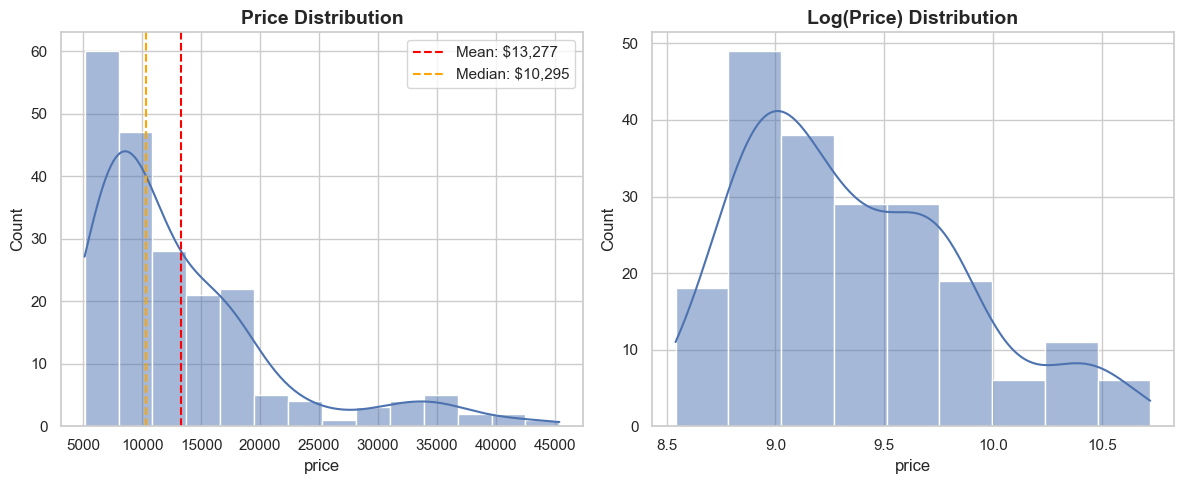

Skewness: 1.78
Skewness (log): 0.67


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw price
sns.histplot(df["price"], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution", fontsize=14, fontweight="bold")
axes[0].axvline(df["price"].mean(), color="red", linestyle="--", label=f"Mean: ${df['price'].mean():,.0f}")
axes[0].axvline(df["price"].median(), color="orange", linestyle="--", label=f"Median: ${df['price'].median():,.0f}")
axes[0].legend()

# Log-transformed price
sns.histplot(np.log1p(df["price"]), kde=True, ax=axes[1])
axes[1].set_title("Log(Price) Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../visualizations/target-distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Skewness: {df['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")

### 4 - Numeric Feature Distributions

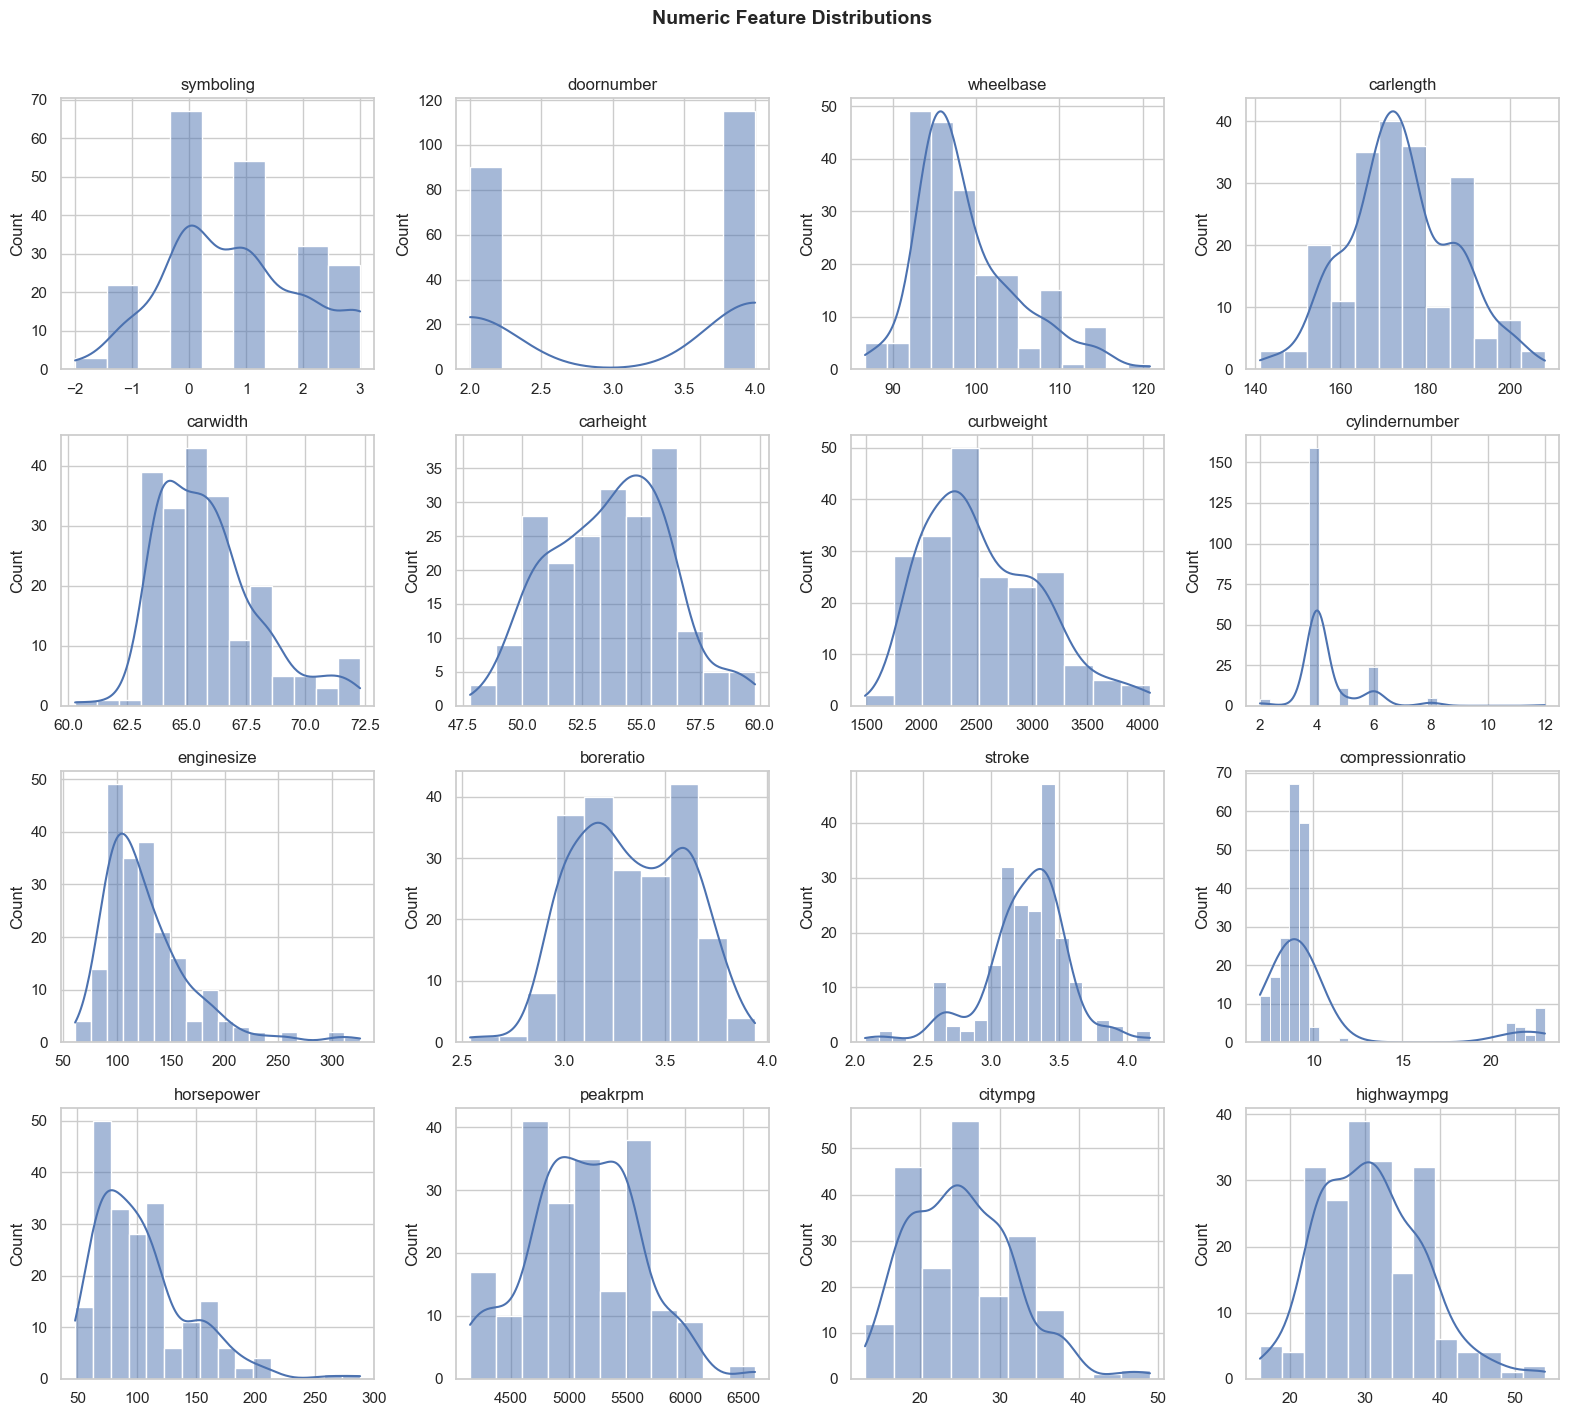

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.drop("price")

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/numeric-distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 5 - Categorical Feature Value Counts

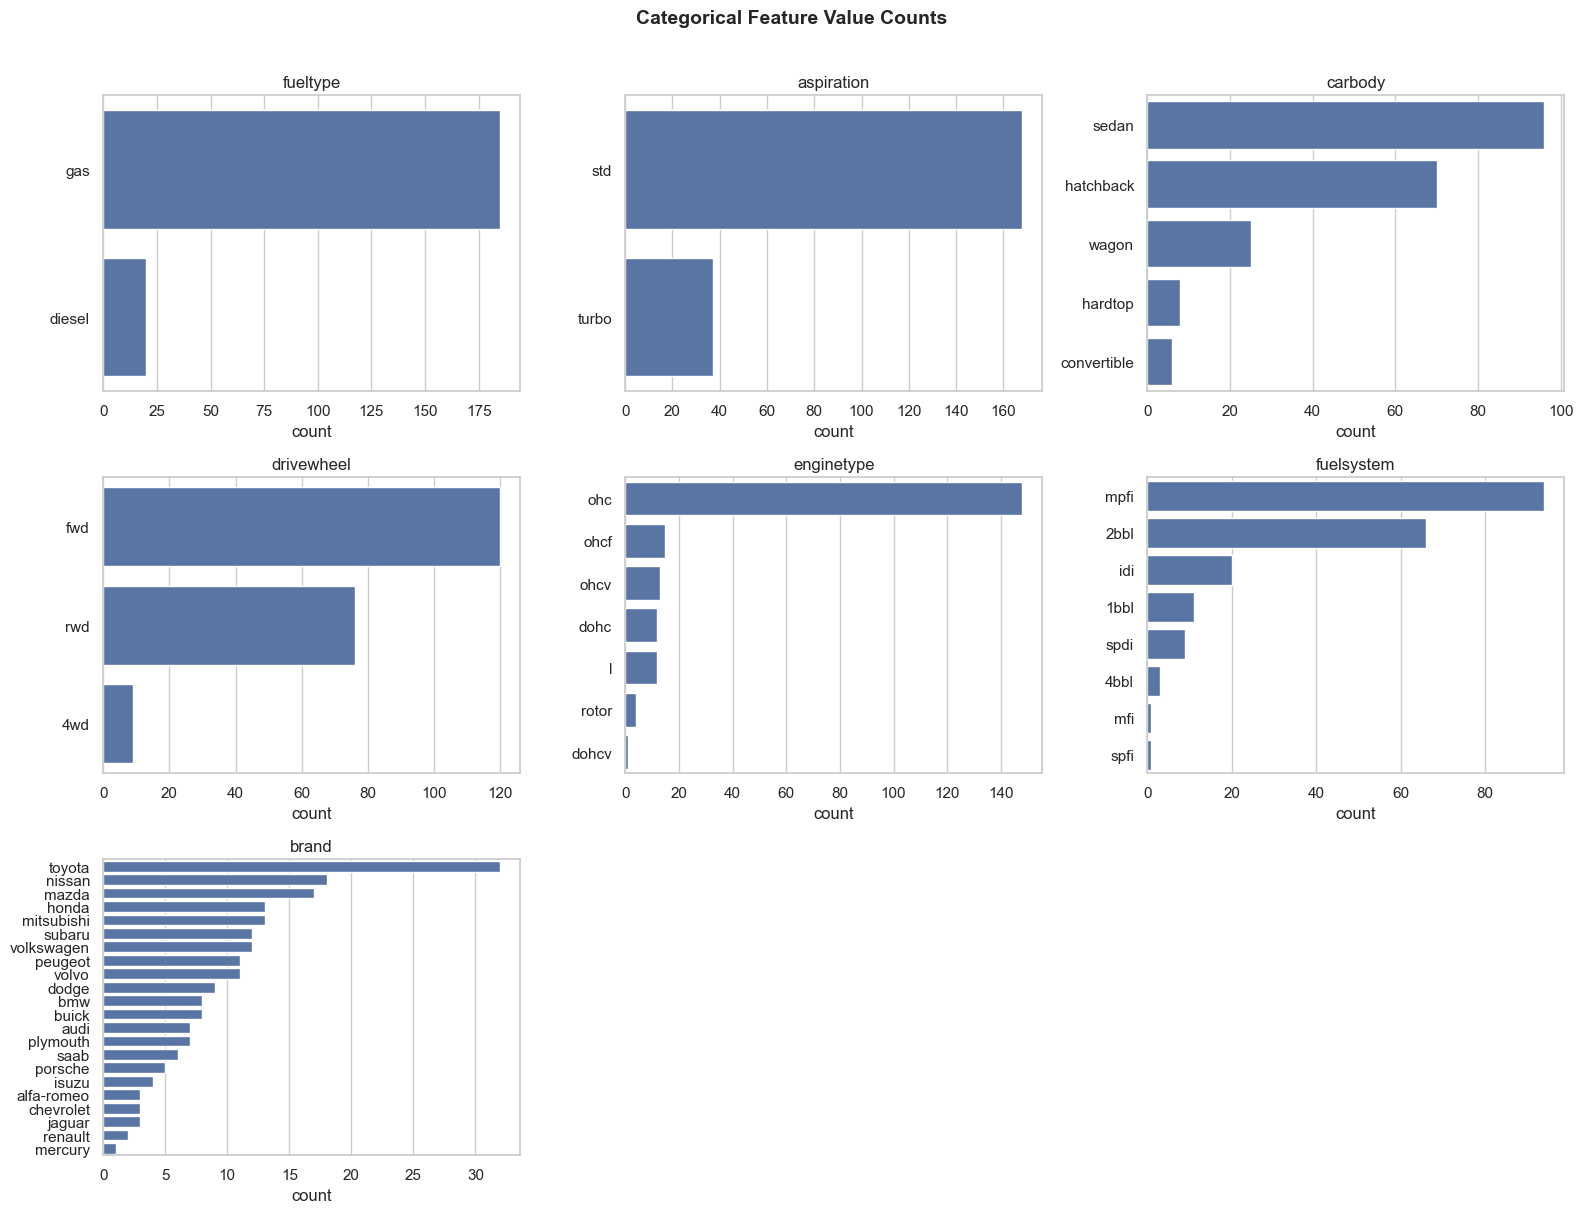

In [6]:
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Value Counts", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/categorical-counts.png", dpi=150, bbox_inches="tight")
plt.show()

### 6 - Correlation Heatmap

Correlation measures the linear relationship between two numeric variables. Values close to +1 or -1 indicate strong relationships; values near 0 indicate weak or no linear relationship. This helps us spot which features might be most predictive of price, and also flags multicollinearity (features that are highly correlated with each other).

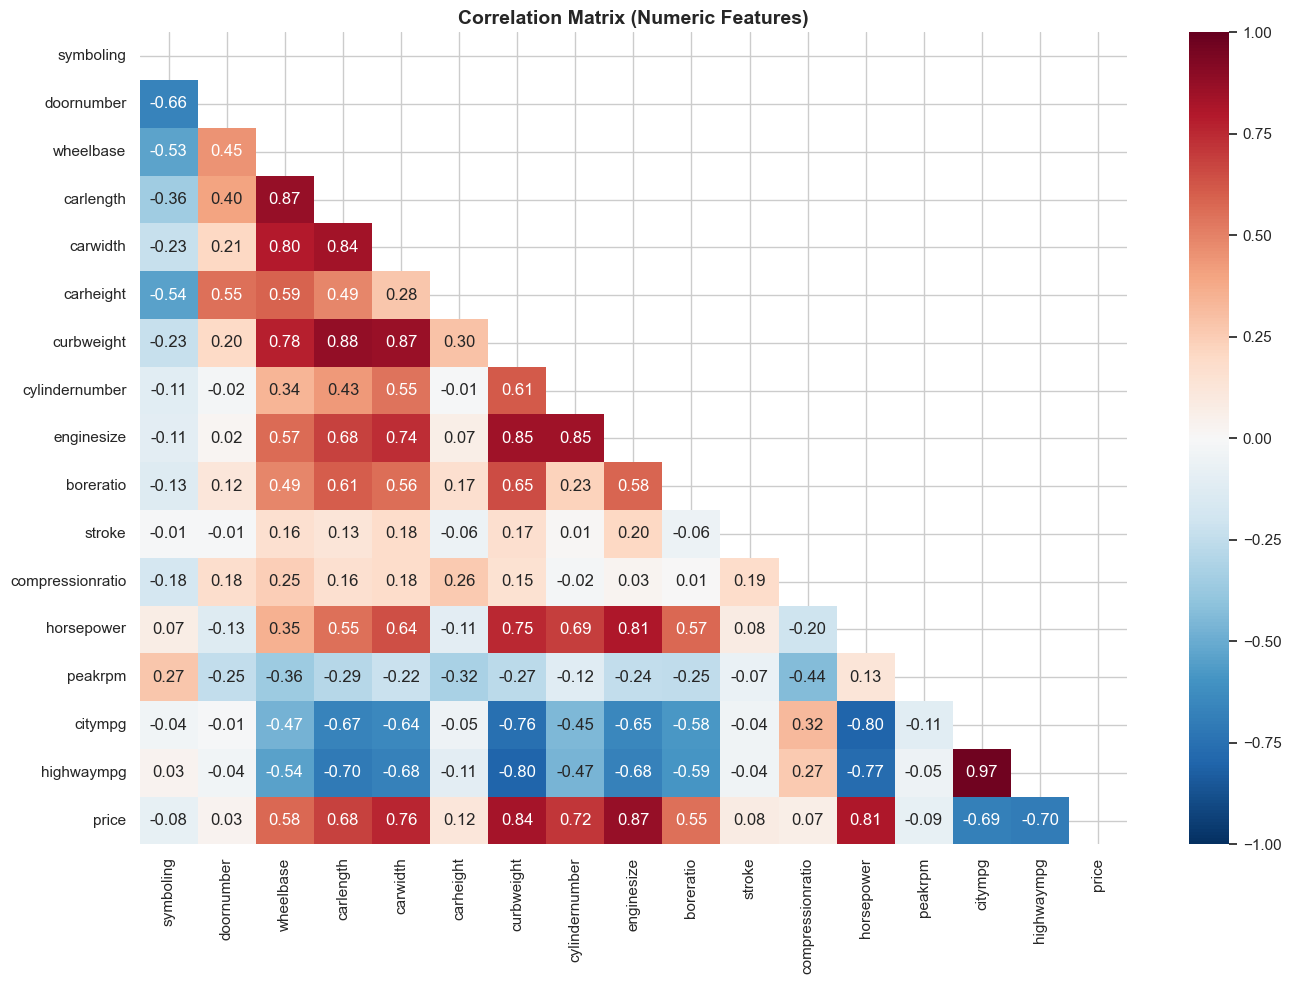

In [7]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/correlation-heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 7 - Top Correlations with Price

In [8]:
price_corr = corr["price"].drop("price").sort_values(key=abs, ascending=False)
print("Correlations with price (sorted by strength):")
print(price_corr.to_string())

Correlations with price (sorted by strength):
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
cylindernumber      0.718305
highwaympg         -0.697599
citympg            -0.685751
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
peakrpm            -0.085267
symboling          -0.079978
stroke              0.079443
compressionratio    0.067984
doornumber          0.031835


### 8 - Scatter Plots: Top Numeric Features vs Price

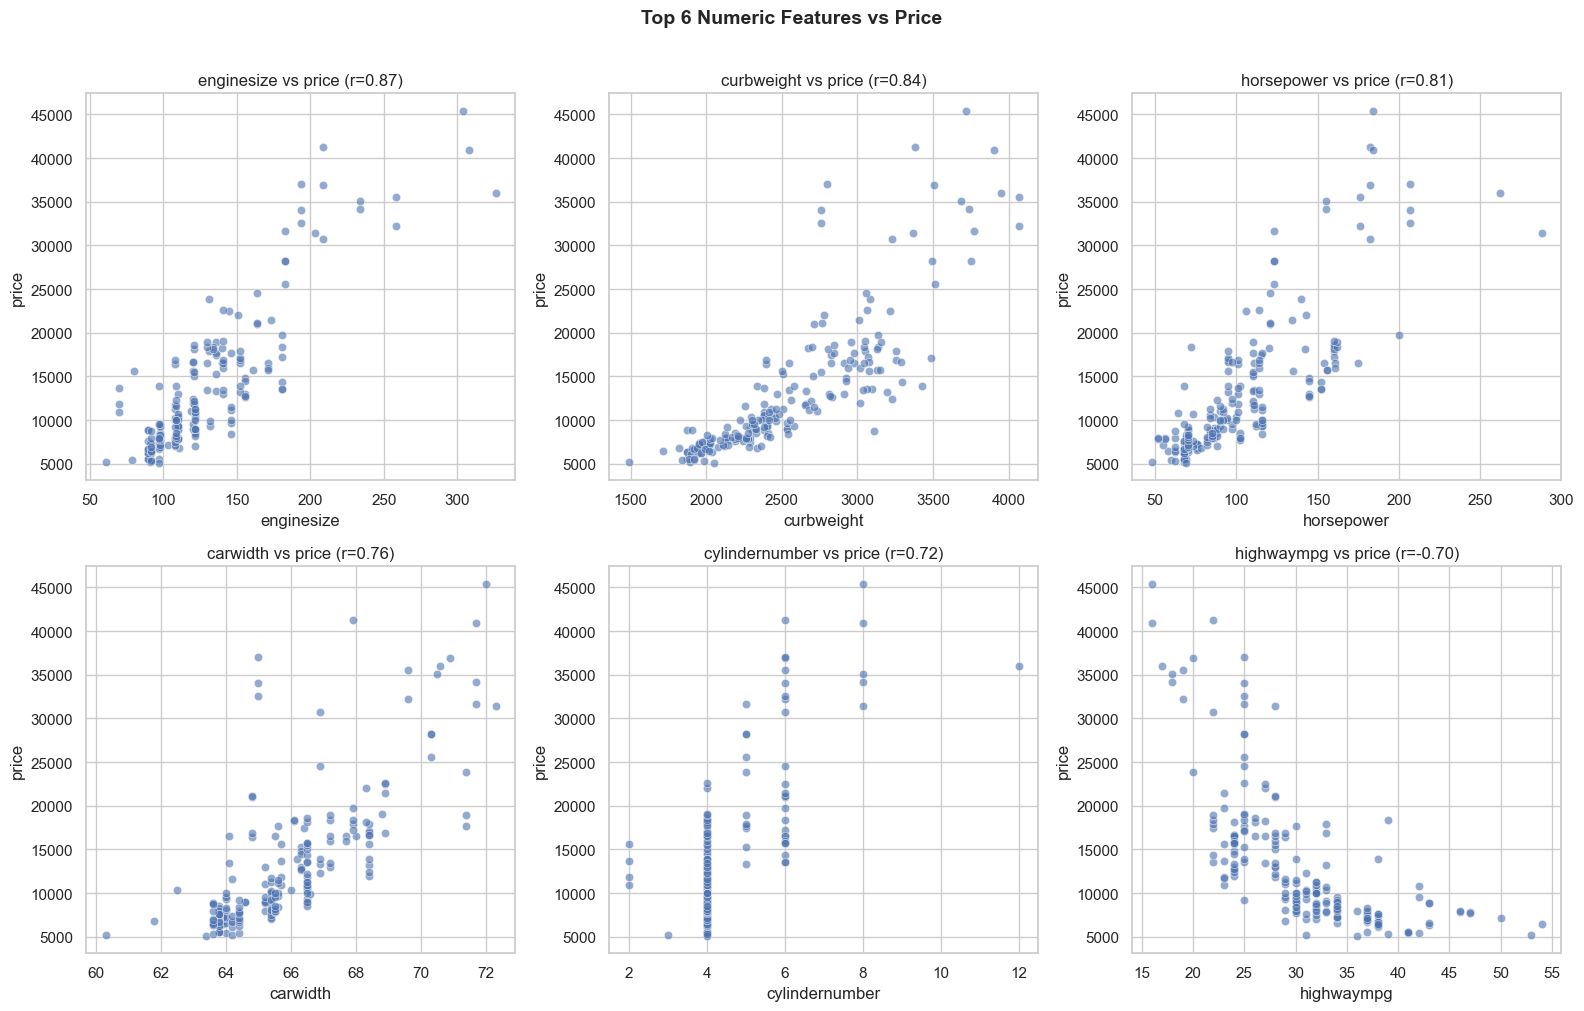

In [9]:
top_features = price_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.scatterplot(data=df, x=col, y="price", alpha=0.6, ax=axes[i])
    axes[i].set_title(f"{col} vs price (r={price_corr[col]:.2f})")

plt.suptitle("Top 6 Numeric Features vs Price", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/top-features-vs-price.png", dpi=150, bbox_inches="tight")
plt.show()

### 9 - Box Plots: Categorical Features vs Price

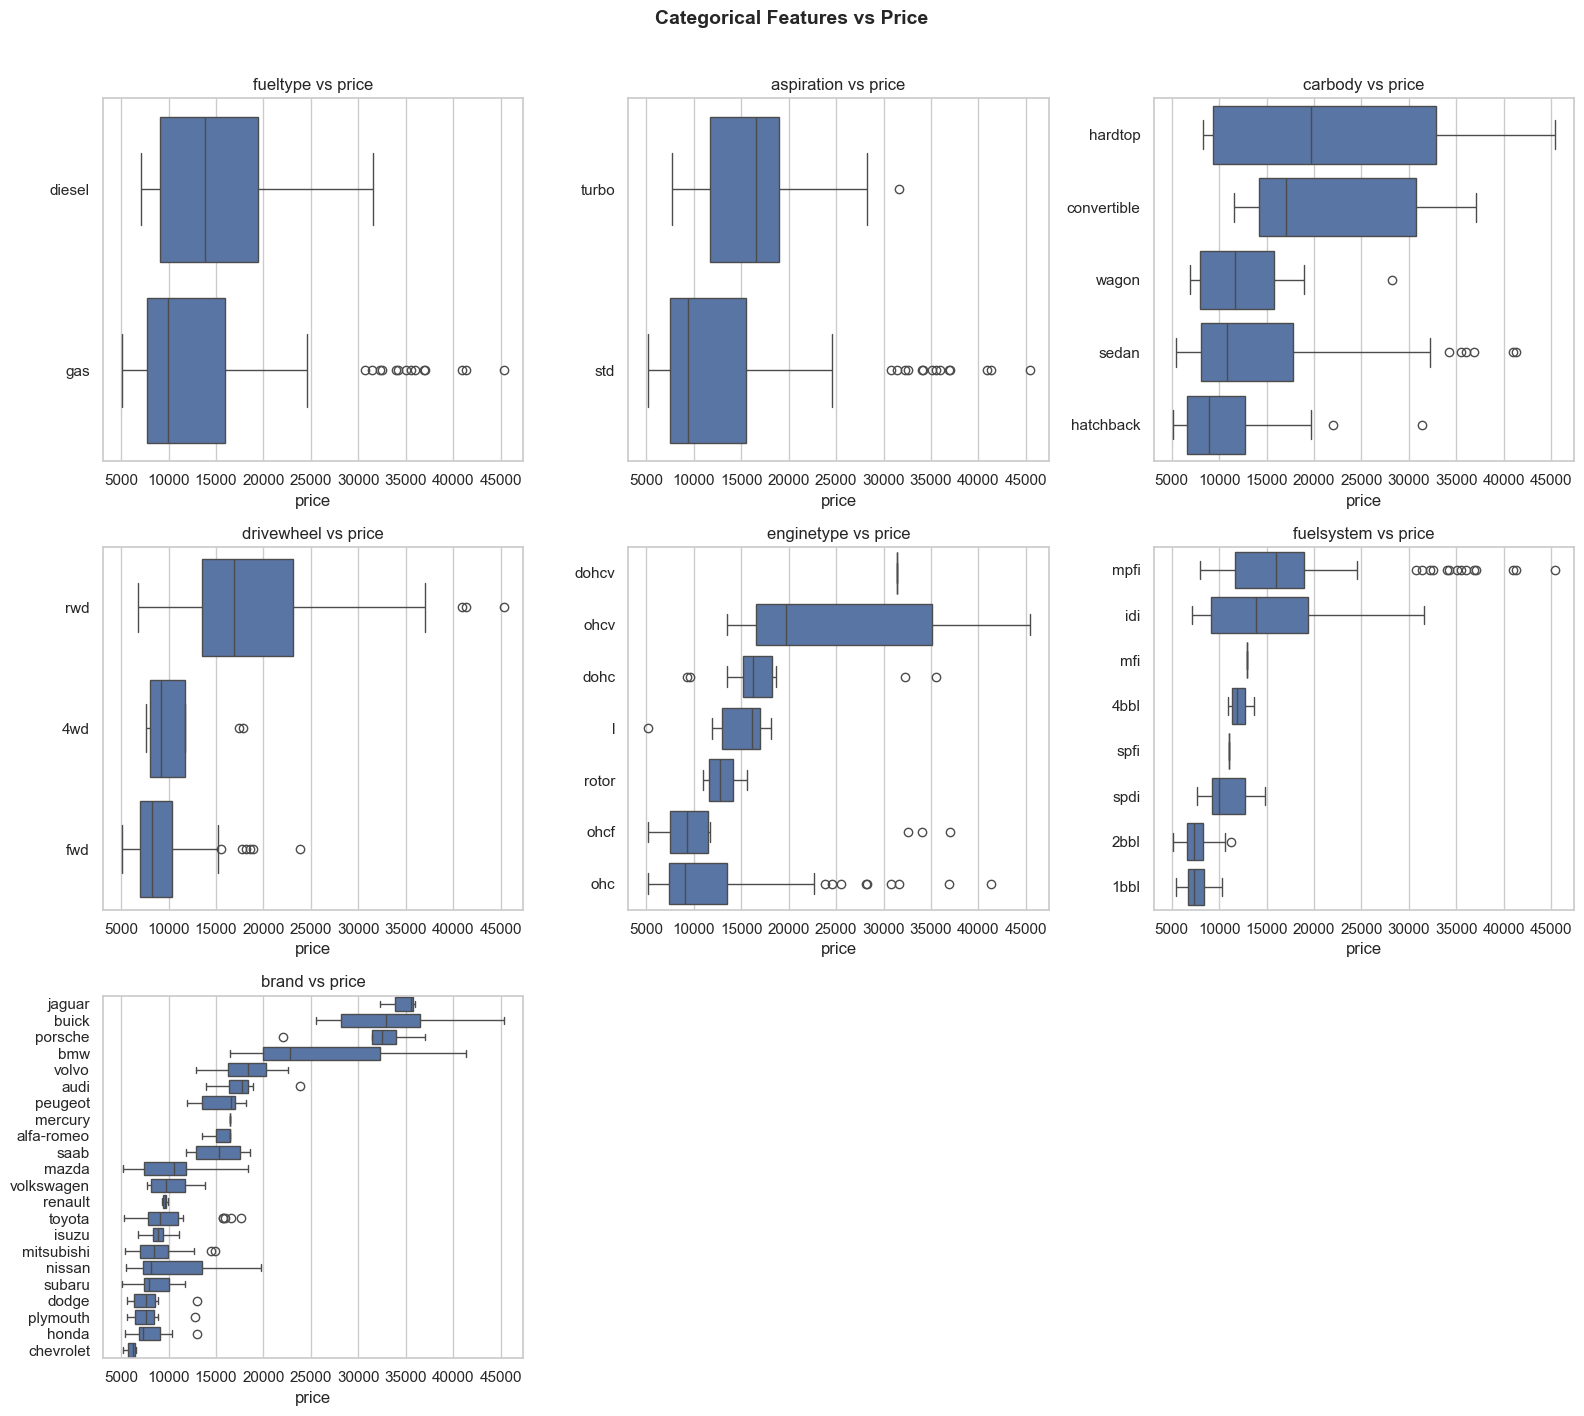

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)["price"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="price", y=col, order=order, ax=axes[i])
    axes[i].set_title(f"{col} vs price")
    axes[i].set_ylabel("")

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features vs Price", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visualizations/categorical-vs-price.png", dpi=150, bbox_inches="tight")
plt.show()

### 10 - Multicollinearity Check

When two features are highly correlated with each other (e.g. `carlength` and `curbweight`), they carry redundant information. Including both can make model coefficients unstable, especially in linear regression. This is worth flagging now, even though we handle it in preprocessing.

In [11]:
# Find feature pairs with correlation > 0.8 (excluding self-correlations)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr_df = high_corr_df.sort_values("correlation", key=abs, ascending=False)
print("Feature pairs with |correlation| > 0.8:\n")
print(high_corr_df.to_string(index=False))

Feature pairs with |correlation| > 0.8:

     feature_1  feature_2  correlation
       citympg highwaympg     0.971337
     carlength curbweight     0.877728
     wheelbase  carlength     0.874587
    enginesize      price     0.874145
      carwidth curbweight     0.867032
    curbweight enginesize     0.850594
cylindernumber enginesize     0.846031
     carlength   carwidth     0.841118
    curbweight      price     0.835305
    enginesize horsepower     0.809769
    horsepower      price     0.808139
    horsepower    citympg    -0.801456


### 11 - Summary

**Target variable:**
- `price` is right-skewed (skewness 1.16). Log transformation reduces this to -0.13, nearly symmetric. Worth considering for model training.

**Strongest predictors of price (|r| > 0.7):**
- `enginesize` (0.87), `curbweight` (0.84), `horsepower` (0.81), `carwidth` (0.76), `cylindernumber` (0.72)
- `highwaympg` (-0.70) and `citympg` (-0.69) are negatively correlated, as expected (expensive cars tend to be less fuel-efficient).

**Weak/irrelevant features (|r| < 0.1):**
- `doornumber`, `compressionratio`, `stroke`, `symboling`, `peakrpm` show little linear relationship with price.

**Multicollinearity concerns (12 pairs with |r| > 0.8):**
- `citympg` and `highwaympg` (0.97) are nearly redundant; keep one or combine them.
- Size-related features (`carlength`, `carwidth`, `curbweight`, `wheelbase`) are highly intercorrelated.
- `enginesize` correlates strongly with `curbweight`, `cylindernumber`, and `horsepower`.
- These clusters of correlated features will need attention during preprocessing to avoid instability in linear models.

**Categorical features:**
- `brand` shows clear price differentiation (e.g. BMW, Jaguar, Porsche at the top; Honda, Chevrolet, Dodge at the bottom).
- `carbody` (hardtop, convertible tend to be pricier) and `drivewheel` (rwd higher than fwd) also show meaningful separation.
- `fueltype` and `aspiration` have moderate separation but are heavily imbalanced (90%+ gas, 82% std).